Predicting Fraud using Paysim Part dataset

In [1]:
#Core libraries
import pandas as pd
import numpy as np

#Visualisation
import seaborn as sns
import matplotlib.pyplot as plt

#Scikit-learn
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve)

#Imbalanced learning
from imblearn.over_sampling import SMOTE

#XGBoost
from xgboost import XGBClassifier

#Scipy
from scipy.stats import uniform, randint


In [2]:
#Import downloaded dataset using file path
csv_path = "/Users/danielhill/Documents/Documents - Daniel’s MacBook Air/Job Applications 2025/NS&I Senior Data Scientist/Paysim_part.csv"

#Load the CSV data into a pandas DataFrame
df = pd.read_csv(csv_path)

#Display the first few rows of the DataFrame
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
#Get info on data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [4]:
#Check for NA's
df.isna().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [5]:
#Check for duplicated rows
df.duplicated().sum()

0

In [6]:
#Investigate ratio of fraudulent and non-fraudulent transactions
df["isFraud"].value_counts(normalize=True)

isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

<Axes: xlabel='type', ylabel='count'>

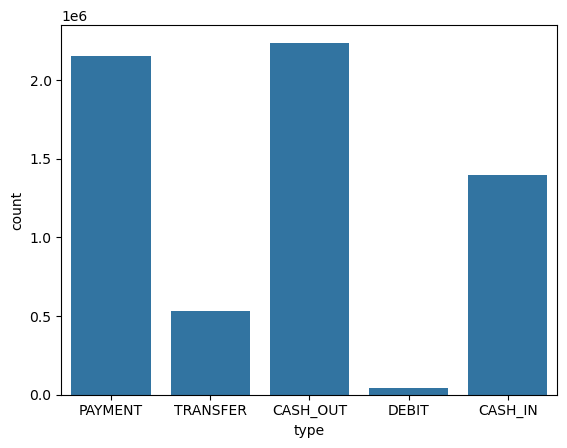

In [7]:
#Investigate 'type' column
df["type"].value_counts()
sns.countplot(x='type', data=df)

In [8]:
#Exploring 'type' by 'is fraud'
df.groupby('type')['isFraud'].mean().sort_values(ascending=False)

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

In [9]:
#Remove unnecessary columns
df2 = df.drop(["nameOrig", "nameDest", "isFlaggedFraud"], axis=1)
df2.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0


Next, I converted the categorical 'type' column into numerical, using one hot encoding. Most machine learning algorithms only work with numerical data, so this will allow this data to be included in the analysis. One hot encoding converts each category into a binary numerical attribute, which benefits from not being ordinal. Once this was done I removed the old 'type' column. 

In [10]:
#Convert categorical column to binary using one-hot encoding
type_categories = df2['type'].unique()
print (type_categories)

encoder= OneHotEncoder()
df_encoded = encoder.fit_transform(df[['type']])
print(df_encoded.toarray())

#Concatenate the original Dataframe to the encoded dataframe
df_encoded = pd.DataFrame(df_encoded.toarray(), columns=encoder.get_feature_names_out(['type']))
df2 = pd.concat([df2, df_encoded], axis=1)

#Remove unneeded categorical column from df2
df2.drop('type', axis=1, inplace=True)
df2.head()

['PAYMENT' 'TRANSFER' 'CASH_OUT' 'DEBIT' 'CASH_IN']
[[0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 ...
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]]


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0.0,0.0,0.0,1.0,0.0
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0.0,0.0,0.0,1.0,0.0
2,1,181.00,181.0,0.00,0.0,0.0,1,0.0,0.0,0.0,0.0,1.0
3,1,181.00,181.0,0.00,21182.0,0.0,1,0.0,1.0,0.0,0.0,0.0
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0.0,0.0,0.0,1.0,0.0


The next step was feature engineering, where I tried to create new variables that may unlock new insights in the data and potentially improve model performance. The first new feature I made was the ratio of the transaction amount and the available balance. I thought that fraudulent transactions may be more likely to be removing all money from the account, so fraudulent transactions might have a ratio of close to 1. 

The second new feature I made was to calculate the difference between account balance before and after transactions in both senders and receivers account. 

The third new feature I created was a binary varible to flag when 'oldbalanceDest', or the receiveing account is zero. I thought there may be a pattern where brand new empty accounts are used to receieve fraudulent funds. 

In [11]:
#Feature engineering

#Compare transaction amount to balance - a ratio of 1 means the account has been emptied
df2['amount_to_balance_ratio'] = df2['amount'] / (df2['oldbalanceOrg'] + 1)

#Calculate difference in balance before/after transaction
df2['balance_diff_orig'] = df2['newbalanceOrig'] - df2['oldbalanceOrg']
df2['balance_diff_dest'] = df2['newbalanceDest'] - df2['oldbalanceDest']

#Calculate transactions where receivers bank account balance is 0 (could be a new account)
df2['zero_dest_balance'] = (df2['oldbalanceDest'] == 0).astype(int)

df2.head()


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,amount_to_balance_ratio,balance_diff_orig,balance_diff_dest,zero_dest_balance
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0.0,0.0,0.0,1.0,0.0,0.057834,-9839.64,0.0,1
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0.0,0.0,0.0,1.0,0.0,0.087731,-1864.28,0.0,1
2,1,181.00,181.0,0.00,0.0,0.0,1,0.0,0.0,0.0,0.0,1.0,0.994505,-181.00,0.0,1
3,1,181.00,181.0,0.00,21182.0,0.0,1,0.0,1.0,0.0,0.0,0.0,0.994505,-181.00,-21182.0,0
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0.0,0.0,0.0,1.0,0.0,0.280788,-11668.14,0.0,1


I produced a correlation matrix for all variables. The only variable that appeared to be correlated with 'isFraud' was 'balance_diff_orig' with a negative correlation of -0.36. As this variable decreased, the likelihood of a transaction being fraudulent increased. This suggests that larger transactions may be more likely to be fraud. 

<Axes: >

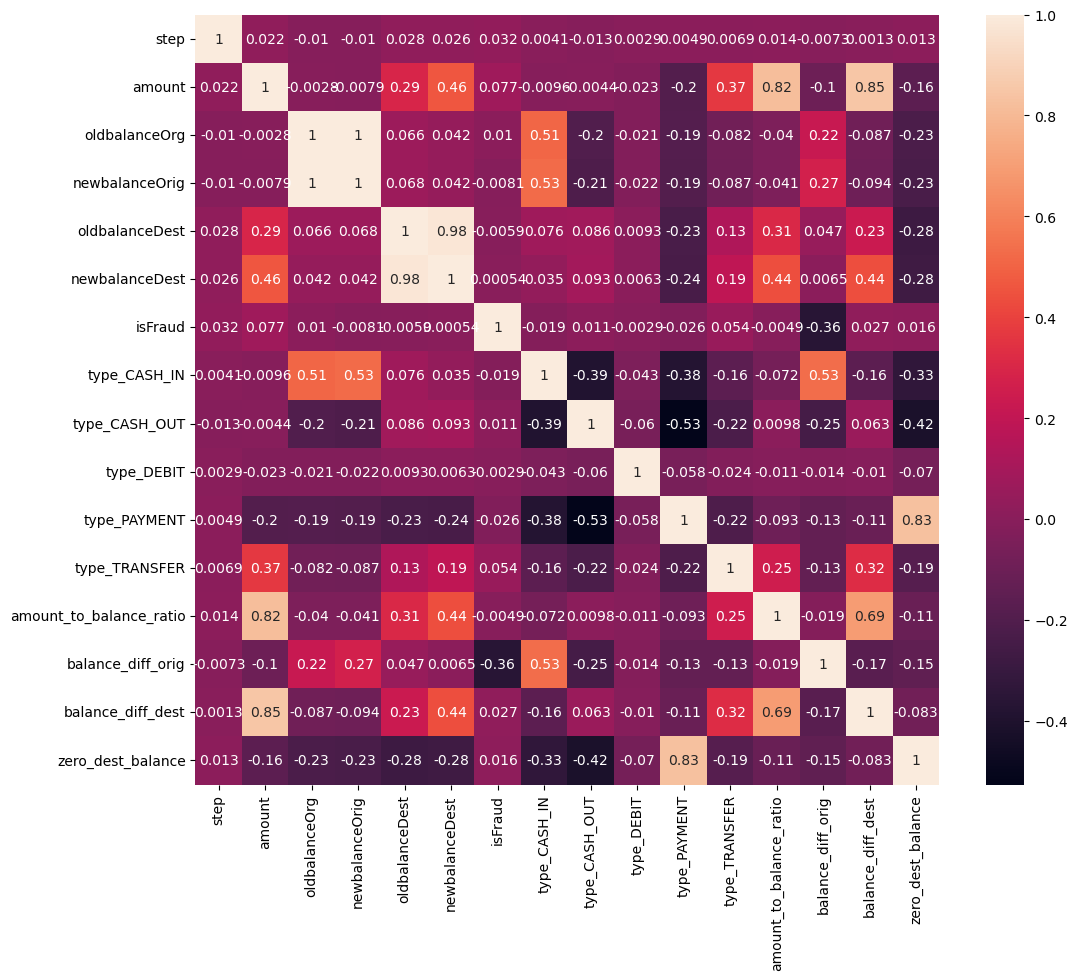

In [12]:
#Correlation matrix
corr = df2.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True)

In [13]:
#Split the data in training and testing sets
#80/20 aplit

#Define features and target as X and y
X = df2.drop(columns='isFraud')  #all predictors
y = df2['isFraud']               #target variable

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42)


Given that the vast majority (99.9%) of transactions were non-fraudulent, I used SMOTE re-sampling technique to generate syntetic examples of the minority class (fraud cases). This balances the dataset without duplicating rows of the minority class, which could lead to overfitting. 

In [14]:
#Resampling
#Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

Next I scaled the data, which avoids models biasing towards large scale features, and also benefits distance based models such as logistic regression. 

In [15]:
#Scale the data

#Initialise scaler
scaler = StandardScaler()

#Fit on training data only, then transform
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)  # test set is not resampled

Next I set up a pipeline to test logistic regression, random forest and xgboost models and compare their results. This would help me choose the method for my final model. I wanted to test a range of models from simple (LR) to complex (RF) to test the level of complexity required for the model. The LR showed very low precision, suggesting that it is too simple of a model so I immediately ruled this one out. The RF showed excellent performance out of the box, but took a long time time to run (~10 mins). While the XGBoost showed average precision but was much faster to run. 

In [16]:
#Testing different models 
#Logistic regression, Random Forest, XGBoost
#Takes ~10 min to run

#Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, n_jobs=-1, eval_metric='logloss', random_state=42),
}

#Results dictionary
results = []

#Loop through each model
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train_resampled)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]  #for ROC AUC

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    })

#Display results as a DataFrame
results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df.sort_values(by='ROC AUC', ascending=False))


Training Logistic Regression...
Training Random Forest...
Training XGBoost...


/Users/danielhill/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [17:29:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model Comparison:
                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
2              XGBoost  0.998723   0.502779  0.990870  0.667076  0.999524
1        Random Forest  0.999900   0.930682  0.996957  0.962680  0.999365
0  Logistic Regression  0.950428   0.024341  0.956786  0.047474  0.991529


/Users/danielhill/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [17:29:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


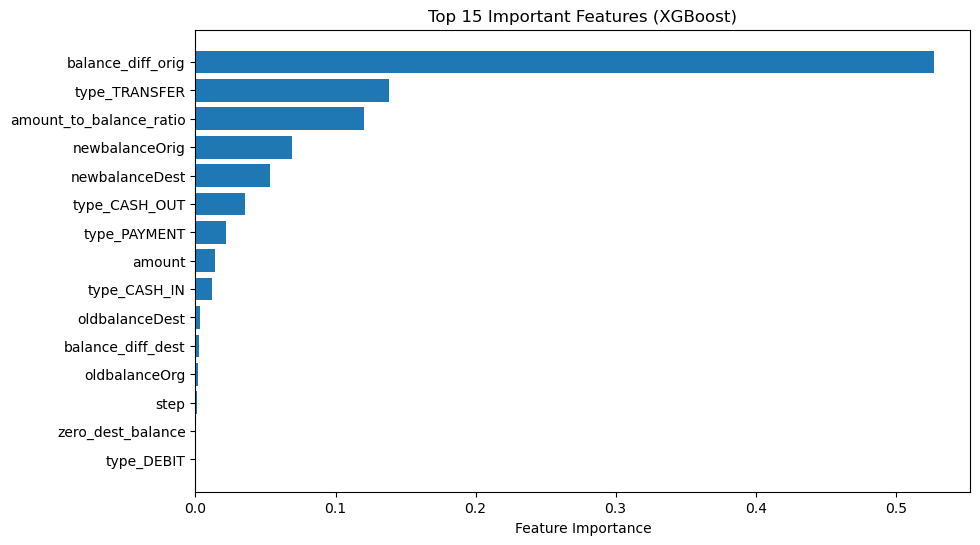

In [17]:
#Re-run XGBoost model
model_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

model_xgb.fit(X_train_scaled, y_train_resampled)

#Get feature importances
importances = model_xgb.feature_importances_
feature_names = X.columns  # assuming X is your original feature set before scaling

#Plot top features
sorted_idx = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 6))
plt.barh(np.array(feature_names)[sorted_idx][:15][::-1], importances[sorted_idx][:15][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 15 Important Features (XGBoost)")
plt.show()


I decided to run XGBoost again, and then run a randomised search to fit the best parameters. I thought that if I can improve precision to the level of the RF, this would be the preferable model due to faster performance. 

In [18]:
#Tweaking XGBoost parameters

#Distributions for random search
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'scale_pos_weight': [1, 5, 10, 20]  
}

#Randomised search — focusing on improving precision
random_search = RandomizedSearchCV(
    estimator=model_xgb,
    param_distributions=param_dist,
    scoring='precision',
    n_iter=25,        # or reduce to 10 for speed
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

#Fit on training data
random_search.fit(X_train_scaled, y_train_resampled)


Fitting 3 folds for each of 25 candidates, totalling 75 fits


/Users/danielhill/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [17:32:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/danielhill/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [17:32:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/danielhill/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [17:33:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/danielhill/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [17:33:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encode

RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                        'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x1558b8350>,
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x158f59e90>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x3576d28d0>,
                                        'scale_pos_weight': [1, 5, 10, 20],
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x357756810>},
                   random_state=42, scoring='precision', verbose=1)

Performance was improved slightly, however it was still not to the level of the RF model. Due to time constraints I decided to pursue random forest for the final model as it works best out of the box. 

In [19]:
best_xgb = random_search.best_estimator_
y_pred = best_xgb.predict(X_test_scaled)

print("Best Parameters:", random_search.best_params_)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Best Parameters: {'colsample_bytree': 0.8185450708005443, 'learning_rate': 0.19533177315875885, 'max_depth': 9, 'n_estimators': 97, 'scale_pos_weight': 10, 'subsample': 0.7265477506155757}

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.48      0.99      0.64      1643

    accuracy                           1.00   1272524
   macro avg       0.74      1.00      0.82   1272524
weighted avg       1.00      1.00      1.00   1272524



As the drawback of RF was running time, I ran feature selection to identify the most important features for the model. This allowed me to remove 6 variables that were low importance for prediction. I was hoping that this would improve the time taken to run without worsening predictive performance. 

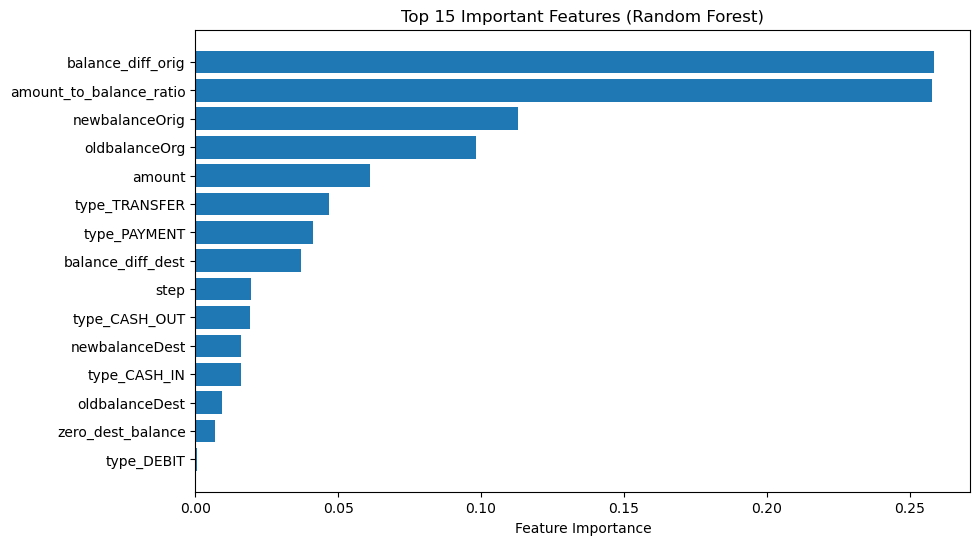

In [20]:
#Feature selection RF
RF_model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)

RF_model.fit(X_train_scaled, y_train_resampled)

#Get feature importances
importances = RF_model.feature_importances_
feature_names = X.columns  # assuming X is your original feature set before scaling

#Plot top features
sorted_idx = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 6))
plt.barh(np.array(feature_names)[sorted_idx][:15][::-1], importances[sorted_idx][:15][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 15 Important Features (Random Forest)")
plt.show()


I removed the variables I deemed unneccessary, and created a new slimmed down version of the dataset. I then ran the preparation process again - splitting the data, resampling and scaling. 

In [21]:
#New data preparation pipeline, removing unnecessary variables

#Drop less important features
important_features = ['balance_diff_orig', 'amount_to_balance_ratio', 'oldbalanceOrg', 'zero_dest_balance',
                     'newbalanceOrig', 'amount', 'type_TRANSFER', 'balance_diff_dest', 'type_PAYMENT']
df_reduced = df2[important_features + ['isFraud']]

#Re-split the data into training and testing sets 
X = df_reduced.drop(columns='isFraud')
y = df_reduced['isFraud']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

#Reset test set index for row alignment
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

#SMOTE (resample only training set)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

#Scale (fit on resampled train, transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)


I ran the final model - this was much quicker to run compared to the full dataset. This took ~5 minutes instead of 10, so runnning time improved by roughly 50%. 

In [22]:
#Run final model
rf_model = RandomForestClassifier(
    n_estimators=100,       #number of trees
    max_depth=None,         #let trees grow fully
    class_weight='balanced', #helps with class imbalance
    n_jobs=-1,               #use all CPU cores
    random_state=42)

#Train on resampled and scaled data
rf_model.fit(X_train_scaled, y_train_resampled)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

The results show that recall was very high (0.99), however precision had fallen to (0.45). The model was great at predicting fraud instances, but made a lot of false positives. I decided to investigate more to see if I could improve precision without harming recall. 

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1588602
           1       0.45      0.99      0.62      2053

    accuracy                           1.00   1590655
   macro avg       0.73      1.00      0.81   1590655
weighted avg       1.00      1.00      1.00   1590655

ROC AUC Score: 0.9992


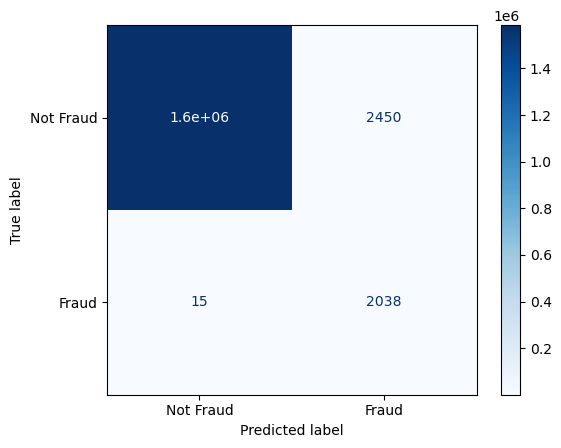

In [23]:
#Predict on test set
y_pred = rf_model.predict(X_test_scaled)

#Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

#Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Fraud", "Fraud"])
disp.plot(cmap='Blues')

#Predict probabilities
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC AUC Score:", round(roc_auc, 4))

I plotted the probabilites on a precision-recall chart, to assess if the standard probability threshold for the model (0.5) was too low, resulting in too many false positives. Looking at the chart, recall is very strong even at very high thresholds, so I increased the probability threshold for the model to 0.8. 

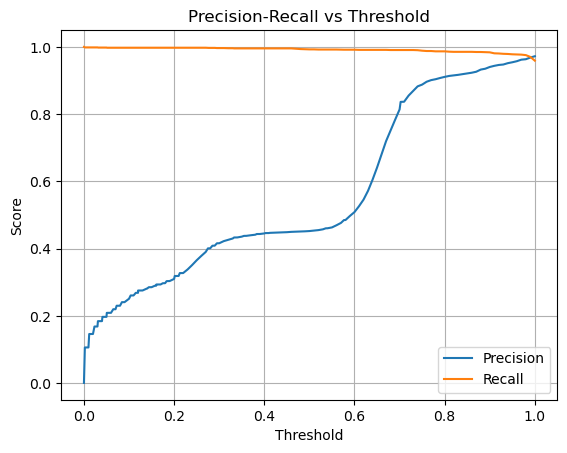

In [24]:
#Predict probabilities
y_scores = rf_model.predict_proba(X_test_scaled)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

#Plot precision-recall curve
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()


After setting the threshold to 0.8, precision increased drastically, to 0.91 - without harming recall at all. Looking at the confusion matrix, the number of false positives has fallen to under 200, while the number of fraud cases missed increased from 15 to 27. I decided this was a reasonable trade off and settled for this as my final model. 

Classification report (threshold = 0.8):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1588602
           1       0.91      0.99      0.95      2053

    accuracy                           1.00   1590655
   macro avg       0.96      0.99      0.97   1590655
weighted avg       1.00      1.00      1.00   1590655



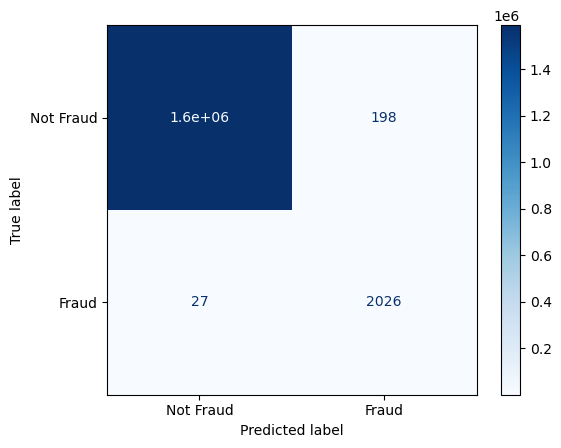

In [25]:
#Get predicted probabilities for fraud
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

#Apply custom threshold (0.8 based off precision-recall chart)
threshold = 0.8
y_pred_thresh = (y_prob >= threshold).astype(int)

#Evaluate performance
print(f"Classification report (threshold = {threshold}):")
print(classification_report(y_test, y_pred_thresh))

#Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_thresh)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Fraud", "Fraud"])
disp.plot(cmap='Blues')


Finally, I defined a function that could be called to show the probability score for an individual row and predicted category. 

In [26]:
#Function to score example row
def score_transaction(row_number, model, X_scaled, threshold=0.8):
    """
    Score a single transaction by row number.

    Parameters:
    - row_number: Index of the row in X_test_scaled
    - model: Trained classifier
    - X_scaled: Scaled test features (X_test_scaled)
    - threshold: Probability threshold for classifying as fraud

    Returns:
    - dict with row number, probability, and prediction
    """
    if row_number < 0 or row_number >= len(X_scaled):
        return {"error": f"Row number {row_number} is out of range."}

    row = X_scaled[row_number].reshape(1, -1)
    prob = model.predict_proba(row)[0][1]
    prediction = "Fraud" if prob >= threshold else "Not Fraud"

    return {
        "row_number": row_number,
        "probability_fraud": round(prob, 4),
        "prediction": prediction
    }


In [27]:
#Example useage
result = score_transaction(4958, rf_model, X_test_scaled, threshold=0.8)
print(result)


{'row_number': 4958, 'probability_fraud': 0.97, 'prediction': 'Fraud'}


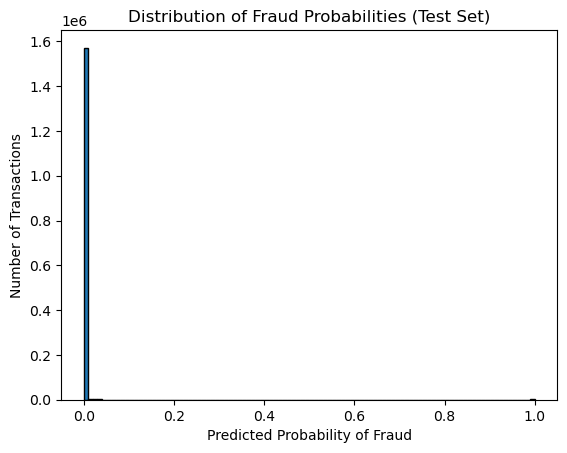

In [28]:
#Plot distribution of probabilities
probs = rf_model.predict_proba(X_test_scaled)[:, 1]
plt.hist(probs, bins=100, edgecolor='black')
plt.xlabel('Predicted Probability of Fraud')
plt.ylabel('Number of Transactions')
plt.title('Distribution of Fraud Probabilities (Test Set)')
plt.show()


This, along with the chart above, shows that the model is generally very certain in its decisions. It obviously performs very well on this test data, but it would need to be further tested on brand new, unseen, data to ensure that this high performance is maintained and not due to overfitting on this specific test set. 

In [29]:
#Testing probabilities of known fraud cases
#Find indices of known frauds in the test set
fraud_indices = y_test[y_test == 1].index

#Extract rows from the scaled test set
fraud_rows = [X_test_scaled[i].reshape(1, -1) for i in fraud_indices]

#Predict probabilities for each fraud row
fraud_probs = [rf_model.predict_proba(row)[0][1] for row in fraud_rows]

#Display top 10 results
for idx, (i, prob) in enumerate(zip(fraud_indices[:10], fraud_probs[:10])):
    print(f"Test row {i}: Probability of fraud = {round(prob, 4)}")


Test row 3266: Probability of fraud = 1.0
Test row 4636: Probability of fraud = 1.0
Test row 4958: Probability of fraud = 0.97
Test row 5722: Probability of fraud = 1.0
Test row 6752: Probability of fraud = 1.0
Test row 8022: Probability of fraud = 1.0
Test row 9604: Probability of fraud = 1.0
Test row 10103: Probability of fraud = 1.0
Test row 10416: Probability of fraud = 1.0
Test row 11591: Probability of fraud = 1.0
